
# TP Machine Learning – Projet End-to-End  
**Sujet : Prédiction du prix des logements (California Housing)**

## Introduction
L’objectif de ce projet est de mettre en pratique l’ensemble des étapes d’un projet de Machine Learning, 
depuis la récupération et la préparation des données jusqu’à l’entraînement de modèles, 
l’évaluation des performances et la réalisation de prédictions.

Le but n’est pas d’obtenir les meilleures performances possibles, mais de comprendre le fonctionnement 
global d’un projet de Machine Learning.



## 1. Chargement des bibliothèques
Nous utilisons les bibliothèques suivantes :
- pandas et numpy pour la manipulation des données
- scikit-learn pour le Machine Learning
- matplotlib pour la visualisation


In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor



## 2. Chargement du jeu de données
Le jeu de données utilisé est le **California Housing Dataset**, un jeu de données réel couramment utilisé 
pour des problèmes de régression.


In [3]:

df = pd.read_csv("../data/raw/california_housing_raw.csv")
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



## 3. Exploration des données
Nous analysons rapidement la structure des données.


In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:

df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



## 4. Préparation des données
- Suppression des doublons
- Séparation des features (X) et de la variable cible (y)


In [6]:

df = df.drop_duplicates().dropna()

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]



## 5. Séparation Train / Test
Nous séparons les données afin d’évaluer les performances du modèle sur des données non vues.


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



## 6. Entraînement de plusieurs modèles
Nous comparons plusieurs modèles de régression :
- Régression Linéaire
- Ridge
- KNN
- RandomForest


In [11]:

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "R2": r2}

results


{'LinearRegression': {'RMSE': 0.7455813830127764, 'R2': 0.5757877060324508},
 'Ridge': {'RMSE': 0.7455567442814778, 'R2': 0.5758157428913686},
 'KNN': {'RMSE': 0.6544719268995516, 'R2': 0.673129908134017},
 'RandomForest': {'RMSE': 0.5038019900730704, 'R2': 0.8063074586513359}}


## 7. Comparaison des performances


In [12]:

pd.DataFrame(results).T


,RMSE,R2
LinearRegression,0.745581,0.575788
Ridge,0.745557,0.575816
KNN,0.654472,0.673130
RandomForest,0.503802,0.806307



Le modèle **RandomForest** présente les meilleures performances avec le RMSE le plus faible et le R² le plus élevé.



## 8. Visualisation des résultats
Comparaison entre les valeurs réelles et les valeurs prédites.


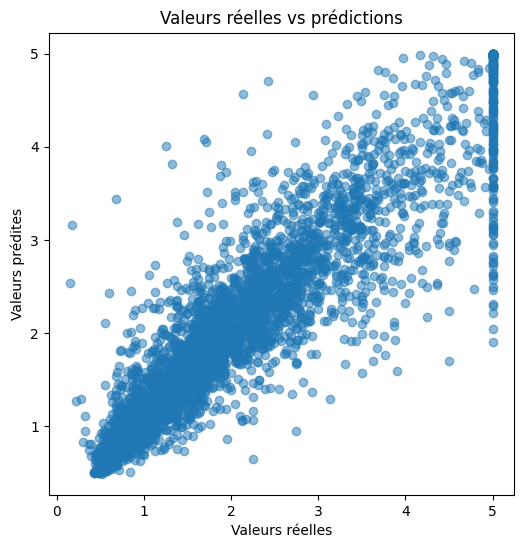

In [13]:

best_model = RandomForestRegressor(n_estimators=200, random_state=42)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_model)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Valeurs réelles vs prédictions")
plt.show()



## 9. Conclusion
Ce projet a permis de mettre en pratique toutes les étapes d’un projet de Machine Learning :
- préparation des données
- entraînement de plusieurs modèles
- évaluation des performances
- visualisation des résultats

Des améliorations possibles incluent l’optimisation des hyperparamètres 
et l’ajout de nouvelles features.
